## Loading Necessary Dependencies

Let's import the libraries that we are going to use for data manipulation, visualization, training the model, etc.
We are going to train the LSTM using PyTorch library.

In [1]:
%matplotlib inline

import glob
from platform import python_version

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import numpy
import pandas as pd
import sklearn
import torch

from scipy.integrate import odeint

import math
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

Using TensorFlow backend.


 ## Load data
 
 Data : number of confirmed cased

 Scenario : Lock-down


##### (a) the real data for Berlin

In [0]:
## USE RKI Cases and death  report

# read the data
deadth_RKI_report = pd.read_csv("https://raw.githubusercontent.com/jgehrcke/covid-19-germany-gae/master/deaths-rki-by-state.csv"
,index_col='time_iso8601',parse_dates=True, header=0)
case_RKI_report = pd.read_csv("https://raw.githubusercontent.com/jgehrcke/covid-19-germany-gae/master/cases-rki-by-state.csv"
,index_col='time_iso8601',parse_dates=True, header=0)

##### (b) from one of your SIR scenarios

In [0]:
df_B = pd.read_csv('data_B.csv')
df_B = df_B.iloc[:,1:]

##### (c) from one of your agent-based scenarios

In [0]:
df_C = pd.read_csv('data_C.csv')
df_C = df_C[df_C['Metric'] == "Infected" ]

df_C[["Avg", "Max"]]= df_C[["Avg", "Max"]].multiply(200) # multiply by population 

In [0]:
df_C[["Avg", "Max"]] = df_C[["Avg", "Max"]].astype(int)

## Data Preprocessing

A )
 For the real data, use data for 01.03.2020-20.04.2020 for training and then predict 21.4.-30.04.2020.

In [0]:
case_RKI_report.index.names = ['Time']

In [0]:
df_A = case_RKI_report.loc['2020-03-01':'2020-04-30', 'DE-BE']

B)  From SEIR model

In [0]:
df_B.set_index('Time', inplace=True)

C) From Agent Based

 use avg number or max

In [0]:
df_C.set_index('Iteration', inplace=True)

In [0]:
df_C_cut = df_C.loc[0:59, 'Avg']

#### Scale

In [0]:
data_A = df_A.to_frame()
data_B = df_B
data_C = df_C_cut.to_frame()

In [0]:
scalerA = MinMaxScaler(feature_range=(0, 1))
A = scalerA.fit_transform(data_A)

In [0]:
scalerB = MinMaxScaler(feature_range=(0, 1))
B = scalerB.fit_transform(data_B)

In [0]:
scalerC = MinMaxScaler(feature_range=(0, 1))
C = scalerC.fit_transform(data_C)

#### transform

In [0]:
def create_dataset(dataset, look_back):
	dataX, dataY = [], []
	for i in range(len(dataset)-look_back-1):
		a = dataset[i:(i+look_back), 0]
		dataX.append(a)
		dataY.append(dataset[i + look_back, 0])
	return numpy.array(dataX), numpy.array(dataY)

In [0]:
look_back = 2
A_X, A_Y = create_dataset(A, look_back)
B_X, B_Y = create_dataset(B, look_back)
C_X, C_Y = create_dataset(C, look_back)

## Prepare Training /Testing set

In [0]:
trainAX = A_X[:50]
trainAY = A_Y[:50]
testAX = A_X[50:]
testAY = A_Y[50:]

trainBX = B_X[:50]
trainBY = B_Y[:50]
testBX = B_X[50:]
testBY = B_Y[50:]

trainCX = C_X[:50]
trainCY = C_Y[:50]
testCX = C_X[50:]
testCY = C_Y[50:]

In [0]:
trainAX = numpy.reshape(trainAX, (trainAX.shape[0], 1, trainAX.shape[1]))
testAX = numpy.reshape(testAX, (testAX.shape[0], 1, testAX.shape[1]))

trainBX = numpy.reshape(trainBX, (trainBX.shape[0], 1, trainBX.shape[1]))
testBX = numpy.reshape(testBX, (testBX.shape[0], 1, testBX.shape[1]))

trainCX = numpy.reshape(trainCX, (trainCX.shape[0], 1, trainCX.shape[1]))
testCX = numpy.reshape(testCX, (testCX.shape[0], 1, testCX.shape[1]))

## Training the LSTM

#### (a)

In [29]:
modelA = Sequential()

modelA.add(LSTM(50, return_sequences=True, input_shape=(1, look_back)))
modelA.add(LSTM(50, return_sequences=True))
modelA.add(LSTM(50, return_sequences=True))
modelA.add(LSTM(50))

modelA.add(Dense(1))
modelA.compile(loss='mean_squared_error', optimizer='adam')
historyA = modelA.fit(trainAX, trainAY, epochs=200, batch_size=1, verbose=2, validation_data=(testAX, testAY))

Train on 50 samples, validate on 7 samples
Epoch 1/200
 - 2s - loss: 0.2083 - val_loss: 0.3403
Epoch 2/200
 - 0s - loss: 0.0481 - val_loss: 3.6828e-05
Epoch 3/200
 - 0s - loss: 0.0157 - val_loss: 0.0071
Epoch 4/200
 - 0s - loss: 0.0053 - val_loss: 0.0097
Epoch 5/200
 - 0s - loss: 0.0044 - val_loss: 0.0151
Epoch 6/200
 - 0s - loss: 0.0038 - val_loss: 0.0043
Epoch 7/200
 - 0s - loss: 0.0054 - val_loss: 2.9939e-04
Epoch 8/200
 - 0s - loss: 0.0028 - val_loss: 2.3876e-04
Epoch 9/200
 - 0s - loss: 0.0022 - val_loss: 0.0079
Epoch 10/200
 - 0s - loss: 0.0016 - val_loss: 5.1463e-04
Epoch 11/200
 - 0s - loss: 0.0013 - val_loss: 0.0023
Epoch 12/200
 - 0s - loss: 0.0011 - val_loss: 7.7088e-04
Epoch 13/200
 - 0s - loss: 8.8877e-04 - val_loss: 3.7762e-04
Epoch 14/200
 - 0s - loss: 8.0175e-04 - val_loss: 1.7567e-04
Epoch 15/200
 - 0s - loss: 5.1298e-04 - val_loss: 8.7479e-05
Epoch 16/200
 - 0s - loss: 5.5351e-04 - val_loss: 4.9219e-04
Epoch 17/200
 - 0s - loss: 3.7432e-04 - val_loss: 4.3600e-05
Epoch

In [0]:
trainPredictA = modelA.predict(trainAX)
testPredictA = modelA.predict(testAX)

In [0]:
# invert predictions
trainPredictA = scalerA.inverse_transform(trainPredictA)
trainAY = scalerA.inverse_transform([trainAY])
testPredictA = scalerA.inverse_transform(testPredictA)
testAY = scalerA.inverse_transform([testAY])

In [32]:
# calculate root mean squared error
trainScoreA = math.sqrt(mean_squared_error(trainAY[0], trainPredictA[:,0]))
print('Train Mean Absolute Error (a):', mean_absolute_error(trainAY[0], trainPredictA[:,0]))
print('Train Score (a): %.2f RMSE' % (trainScoreA))

testScoreA = math.sqrt(mean_squared_error(testAY[0], testPredictA[:,0]))
print('Test Mean Absolute Error (a):', mean_absolute_error(testAY[0], testPredictA[:,0]))
print('Test Score (a): %.2f RMSE' % (testScoreA))

Train Mean Absolute Error (a): 43.59477432250978
Train Score (a): 55.92 RMSE
Test Mean Absolute Error (a): 85.66636439732143
Test Score (a): 90.39 RMSE


plot loss

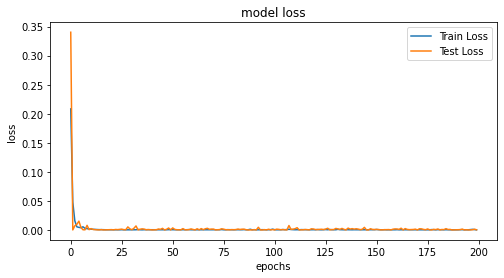

In [33]:
plt.figure(figsize=(8,4))
plt.plot(historyA.history['loss'], label='Train Loss')
plt.plot(historyA.history['val_loss'], label='Test Loss')
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epochs')
plt.legend(loc='upper right')
plt.show()

plot prediction

In [0]:
trainPredictPlotA = numpy.empty_like(A)
trainPredictPlotA[:, :] = numpy.nan
trainPredictPlotA[0:len(trainPredictA), :] = trainPredictA

In [0]:
testPredictPlotA = numpy.empty_like(A)
testPredictPlotA[:, :] = numpy.nan
testPredictPlotA[len(trainPredictA):len(A)-look_back-1, :] = testPredictA

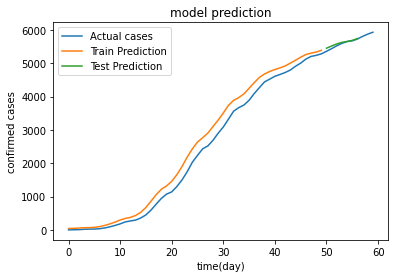

In [37]:
plt.plot(scalerA.inverse_transform(A), label='Actual cases')
plt.plot(trainPredictPlotA, label='Train Prediction')
plt.plot(testPredictPlotA, label='Test Prediction')

plt.title('model prediction')
plt.ylabel('confirmed cases')
plt.xlabel('time(day)')
plt.legend(loc='upper left')
plt.show()

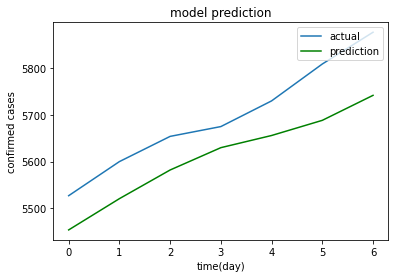

In [38]:
plt.plot(testAY[0], label="actual")
plt.plot(testPredictA, label="prediction", color='green')

plt.title('model prediction')
plt.ylabel('confirmed cases')
plt.xlabel('time(day)')
plt.legend(loc='upper right')
plt.show()

#### (b)

In [39]:
modelB = Sequential()

modelB.add(LSTM(50, return_sequences=True, input_shape=(1, look_back)))
modelB.add(LSTM(50, return_sequences=True))
modelB.add(LSTM(50, return_sequences=True))
modelB.add(LSTM(50))

modelB.add(Dense(1))
modelB.compile(loss='mean_squared_error', optimizer='adam')
historyB = modelB.fit(trainBX, trainBY, epochs=200, batch_size=1, verbose=2, validation_data=(testBX, testBY))

Train on 50 samples, validate on 7 samples
Epoch 1/200
 - 2s - loss: 0.0503 - val_loss: 0.7651
Epoch 2/200
 - 0s - loss: 0.0442 - val_loss: 0.6308
Epoch 3/200
 - 0s - loss: 0.0379 - val_loss: 0.3850
Epoch 4/200
 - 0s - loss: 0.0118 - val_loss: 0.5088
Epoch 5/200
 - 0s - loss: 0.0027 - val_loss: 0.0040
Epoch 6/200
 - 0s - loss: 0.0029 - val_loss: 0.6116
Epoch 7/200
 - 0s - loss: 0.0047 - val_loss: 0.0035
Epoch 8/200
 - 0s - loss: 0.0033 - val_loss: 0.0715
Epoch 9/200
 - 0s - loss: 0.0031 - val_loss: 0.2467
Epoch 10/200
 - 0s - loss: 0.0019 - val_loss: 0.0062
Epoch 11/200
 - 0s - loss: 0.0020 - val_loss: 0.0842
Epoch 12/200
 - 0s - loss: 0.0013 - val_loss: 0.0410
Epoch 13/200
 - 0s - loss: 6.5581e-04 - val_loss: 0.1395
Epoch 14/200
 - 0s - loss: 7.5960e-04 - val_loss: 0.0198
Epoch 15/200
 - 0s - loss: 6.7464e-04 - val_loss: 0.0841
Epoch 16/200
 - 0s - loss: 5.1935e-04 - val_loss: 0.0706
Epoch 17/200
 - 0s - loss: 4.8891e-04 - val_loss: 0.0213
Epoch 18/200
 - 0s - loss: 2.3524e-04 - val_l

In [0]:
trainPredictB = modelB.predict(trainBX)
testPredictB = modelB.predict(testBX)

In [0]:
# invert predictions
trainPredictB = scalerB.inverse_transform(trainPredictB)
trainBY = scalerB.inverse_transform([trainBY])
testPredictB = scalerB.inverse_transform(testPredictB)
testBY = scalerB.inverse_transform([testBY])

In [42]:
# calculate root mean squared error
trainScoreB = math.sqrt(mean_squared_error(trainBY[0], trainPredictB[:,0]))
print('Train Mean Absolute Error (b):', mean_absolute_error(trainBY[0], trainPredictB[:,0]))
print('Train Score (b): %.2f RMSE' % (trainScoreB))

testScoreB = math.sqrt(mean_squared_error(testBY[0], testPredictB[:,0]))
print('Test Mean Absolute Error (b):', mean_absolute_error(testBY[0], testPredictB[:,0]))
print('Test Score (b): %.2f RMSE' % (testScoreB))

Train Mean Absolute Error (b): 190.86482112884522
Train Score (b): 236.24 RMSE
Test Mean Absolute Error (b): 2020.625
Test Score (b): 2599.96 RMSE


plot loss

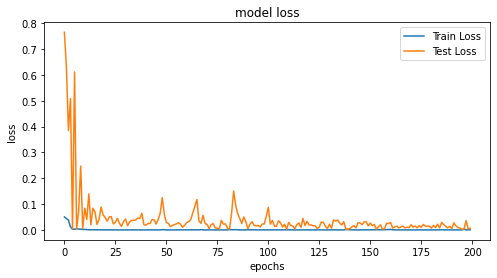

In [43]:
plt.figure(figsize=(8,4))
plt.plot(historyB.history['loss'], label='Train Loss')
plt.plot(historyB.history['val_loss'], label='Test Loss')
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epochs')
plt.legend(loc='upper right')
plt.show()

plot prediction

In [0]:
trainPredictPlotB = numpy.empty_like(B)
trainPredictPlotB[:, :] = numpy.nan
trainPredictPlotB[0:len(trainPredictB), :] = trainPredictB

In [0]:
testPredictPlotB = numpy.empty_like(B)
testPredictPlotB[:, :] = numpy.nan
testPredictPlotB[len(trainPredictB):len(B)-look_back-1, :] = testPredictB

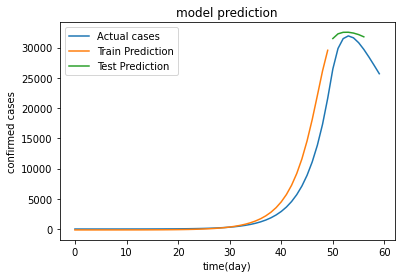

In [46]:
plt.plot(scalerB.inverse_transform(B), label='Actual cases')
plt.plot(trainPredictPlotB, label='Train Prediction')
plt.plot(testPredictPlotB, label='Test Prediction')

plt.title('model prediction')
plt.ylabel('confirmed cases')
plt.xlabel('time(day)')
plt.legend(loc='upper left')
plt.show()

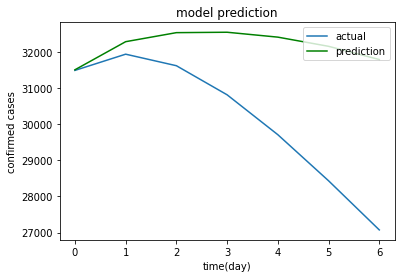

In [47]:
plt.plot(testBY[0], label="actual")
plt.plot(testPredictB, label="prediction", color='green')

plt.title('model prediction')
plt.ylabel('confirmed cases')
plt.xlabel('time(day)')
plt.legend(loc='upper right')
plt.show()

#### (c)

In [48]:
modelC = Sequential()

modelC.add(LSTM(50, return_sequences=True, input_shape=(1, look_back)))
modelC.add(LSTM(50, return_sequences=True))
modelC.add(LSTM(50, return_sequences=True))
modelC.add(LSTM(50))

modelC.add(Dense(1))
modelC.compile(loss='mean_squared_error', optimizer='adam')
historyC = modelC.fit(trainCX, trainCY, epochs=200, batch_size=1, verbose=2, validation_data=(testCX, testCY))

Train on 50 samples, validate on 7 samples
Epoch 1/200
 - 2s - loss: 0.2403 - val_loss: 0.1030
Epoch 2/200
 - 0s - loss: 0.0624 - val_loss: 0.0983
Epoch 3/200
 - 0s - loss: 0.0232 - val_loss: 0.0422
Epoch 4/200
 - 0s - loss: 0.0103 - val_loss: 0.0188
Epoch 5/200
 - 0s - loss: 0.0070 - val_loss: 0.0121
Epoch 6/200
 - 0s - loss: 0.0076 - val_loss: 0.0101
Epoch 7/200
 - 0s - loss: 0.0091 - val_loss: 0.0101
Epoch 8/200
 - 0s - loss: 0.0076 - val_loss: 0.0064
Epoch 9/200
 - 0s - loss: 0.0079 - val_loss: 0.0091
Epoch 10/200
 - 0s - loss: 0.0056 - val_loss: 0.0085
Epoch 11/200
 - 0s - loss: 0.0065 - val_loss: 0.0093
Epoch 12/200
 - 0s - loss: 0.0063 - val_loss: 0.0093
Epoch 13/200
 - 0s - loss: 0.0078 - val_loss: 0.0069
Epoch 14/200
 - 0s - loss: 0.0080 - val_loss: 0.0050
Epoch 15/200
 - 0s - loss: 0.0054 - val_loss: 0.0074
Epoch 16/200
 - 0s - loss: 0.0052 - val_loss: 0.0065
Epoch 17/200
 - 0s - loss: 0.0056 - val_loss: 0.0045
Epoch 18/200
 - 0s - loss: 0.0046 - val_loss: 0.0049
Epoch 19/200

In [0]:
trainPredictC = modelC.predict(trainCX)
testPredictC = modelC.predict(testCX)

In [0]:
# invert predictions
trainPredictC = scalerC.inverse_transform(trainPredictC)
trainCY = scalerC.inverse_transform([trainCY])
testPredictC = scalerC.inverse_transform(testPredictC)
testCY = scalerC.inverse_transform([testCY])

In [51]:
# calculate root mean squared error
trainScoreC = math.sqrt(mean_squared_error(trainCY[0], trainPredictC[:,0]))
print('Train Mean Absolute Error (c):', mean_absolute_error(trainCY[0], trainPredictC[:,0]))
print('Train Score (c): %.2f RMSE' % (trainScoreC))

testScoreC = math.sqrt(mean_squared_error(testCY[0], testPredictC[:,0]))
print('Test Mean Absolute Error (c):', mean_absolute_error(testCY[0], testPredictC[:,0]))
print('Test Score (c): %.2f RMSE' % (testScoreC))

Train Mean Absolute Error (c): 1.0741915130615234
Train Score (c): 1.33 RMSE
Test Mean Absolute Error (c): 0.6038237980433873
Test Score (c): 0.78 RMSE


plot loss

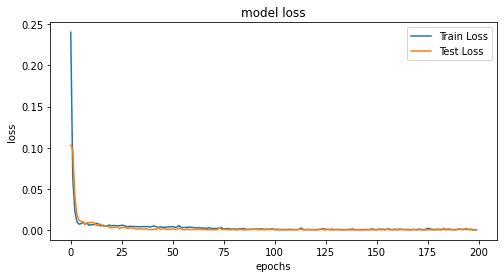

In [52]:
plt.figure(figsize=(8,4))
plt.plot(historyC.history['loss'], label='Train Loss')
plt.plot(historyC.history['val_loss'], label='Test Loss')
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epochs')
plt.legend(loc='upper right')
plt.show()

plot prediction

In [0]:
trainPredictPlotC = numpy.empty_like(C)
trainPredictPlotC[:, :] = numpy.nan
trainPredictPlotC[0:len(trainPredictC), :] = trainPredictC

In [0]:
testPredictPlotC = numpy.empty_like(C)
testPredictPlotC[:, :] = numpy.nan
testPredictPlotC[len(trainPredictC):len(C)-look_back-1, :] = testPredictC

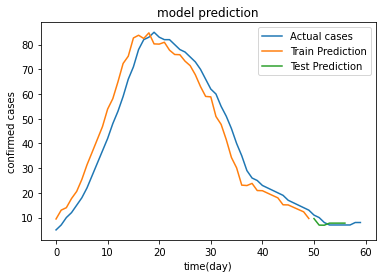

In [55]:
plt.plot(scalerC.inverse_transform(C), label='Actual cases')
plt.plot(trainPredictPlotC, label='Train Prediction')
plt.plot(testPredictPlotC, label='Test Prediction')

plt.title('model prediction')
plt.ylabel('confirmed cases')
plt.xlabel('time(day)')
plt.legend(loc='upper right')
plt.show()

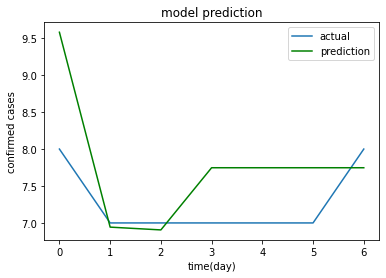

In [56]:
plt.plot(testCY[0], label="actual")
plt.plot(testPredictC, label="prediction", color='green')

plt.title('model prediction')
plt.ylabel('confirmed cases')
plt.xlabel('time(day)')
plt.legend(loc='upper right')
plt.show()